# 02 — Exploration de l’agressivité chimique

Objectif : explorer les deux feuilles du classeur, calculer Larson et préparer la modélisation.

## 1. Configuration

In [4]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
DATA_RAW=PROJECT_ROOT/"data"/"raw"; DATA_PROCESSED=PROJECT_ROOT/"data"/"processed"
FIGURES=PROJECT_ROOT/"reports"/"figures"; RESULTS=PROJECT_ROOT/"reports"/"results"; MODELS=PROJECT_ROOT/"models"
for p in [DATA_PROCESSED,FIGURES,RESULTS,MODELS]: p.mkdir(parents=True,exist_ok=True)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
RANDOM_STATE=42
pd.set_option("display.max_columns",100)

In [5]:
from src.data_cleaning import load_water_quality,basic_cleaning,data_quality_report,save_processed
from src.indices_chimiques import add_larson_features

## 2. Chargement des feuilles

In [6]:
p=DATA_RAW/"water_quality.xlsx"
mhl=basic_cleaning(load_water_quality(p,"MHLATHUZE")); luv=basic_cleaning(load_water_quality(p,"LUVUVU"))
print("MHLATHUZE",mhl.shape,"LUVUVU",luv.shape)
display(mhl.head()); display(luv.head())

MHLATHUZE (198, 19) LUVUVU (84, 23)


,EC,TDS,pH,HCO3,Cl,SO4,Ca,K,Mg,Na,NO3,Al,Co,Cu,Fe,Mn,Ni,Zn,Y
0,246.3,177.3,5.08,70.15,27.329,9.881,41.30,5.86,9.49,13.7,1.597,0.4060,0.000,0.0671,0.0000,0.1120,0.0061,0.0,0
1,1058.0,711.0,6.22,207.40,145.702,18.918,87.20,8.14,52.60,52.4,16.519,0.7200,0.349,0.1004,0.0720,0.2805,0.0914,0.0,2
2,137.0,99.0,6.62,70.15,12.382,2.155,6.98,5.35,3.31,11.3,6.487,0.0405,0.000,0.0000,0.0000,0.0042,0.0000,0.0,0
3,1412.0,957.0,6.68,216.55,226.381,135.851,82.30,6.25,44.80,43.3,3.200,0.6805,0.265,0.1530,0.0459,0.2085,0.0739,0.0,2
4,1254.0,863.0,6.98,341.60,129.445,68.583,102.00,5.00,107.00,47.2,2.570,0.6815,0.312,0.0508,0.0831,0.2440,0.0560,0.0,2


,pH,EC,TDS,Na,K,Ca,Mg,Cl,HCO3,SO4,NO3,F,Ag,B,Cd,Co,Cr,Cu,Fe,Mn,Pb,Zn,Y
0,6.12,253,161.92,12.1807,2.00000,22.0000,7.83888,22.0000,89.670,3.95,2.0,0.173,0.001578,0.037612,0.004035,0.003035,0.003363,0.002772,0.029466,0.000944,0.015547,0.001551,0
1,5.83,828,529.92,62.0259,5.00000,72.0000,23.00000,36.0000,399.000,6.69,3.0,0.275,0.001010,0.062478,0.003196,0.006373,0.003127,0.000000,0.024645,0.000800,0.016118,0.001209,0
2,5.94,975,624.00,89.5817,3.66254,82.0000,27.00000,66.2206,476.000,12.00,2.0,0.334,0.004440,0.078676,0.004125,0.004615,0.004192,0.001110,0.022768,0.001232,0.014121,0.002003,0
3,5.94,773,494.72,45.5573,2.00000,74.0000,29.00000,99.3309,288.225,14.90,12.0,0.203,0.002310,0.040045,0.003331,0.005476,0.003370,0.003724,0.024781,0.001279,0.016280,0.020944,0
4,6.05,596,381.44,29.0000,3.00000,48.0644,22.00000,54.0000,245.000,7.82,15.0,0.123,0.000424,0.023671,0.002965,0.007938,0.003638,0.000000,0.023897,0.001283,0.017633,0.001436,0


## 3. Contrôle qualité

In [7]:
print(list(mhl.columns)); print(list(luv.columns)); display(data_quality_report(mhl)); display(data_quality_report(luv))

['EC', 'TDS', 'pH', 'HCO3', 'Cl', 'SO4', 'Ca', 'K', 'Mg', 'Na', 'NO3', 'Al', 'Co', 'Cu', 'Fe', 'Mn', 'Ni', 'Zn', 'Y']
['pH', 'EC', 'TDS', 'Na', 'K', 'Ca', 'Mg', 'Cl', 'HCO3', 'SO4', 'NO3', 'F', 'Ag', 'B', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Mn', 'Pb', 'Zn', 'Y']


,dtype,missing_n,missing_pct,n_unique
EC,float64,0,0.0,193
TDS,float64,0,0.0,197
pH,float64,0,0.0,145
HCO3,float64,0,0.0,172
Cl,float64,0,0.0,192
SO4,float64,0,0.0,184
Ca,float64,0,0.0,172
K,float64,0,0.0,159
Mg,float64,0,0.0,170
Na,float64,0,0.0,182


,dtype,missing_n,missing_pct,n_unique
pH,float64,0,0.0,66
EC,int64,0,0.0,80
TDS,float64,0,0.0,80
Na,float64,0,0.0,72
K,float64,0,0.0,50
Ca,float64,0,0.0,56
Mg,float64,0,0.0,31
Cl,float64,0,0.0,55
HCO3,float64,0,0.0,72
SO4,float64,0,0.0,77


## 4. Colonnes communes

In [8]:
common=sorted(set(mhl.columns)&set(luv.columns)); chem=[c for c in ["pH","EC","TDS","Na","K","Ca","Mg","Cl","HCO3","SO4","NO3"] if c in common]
print(common); print("Variables retenues :",chem)

['Ca', 'Cl', 'Co', 'Cu', 'EC', 'Fe', 'HCO3', 'K', 'Mg', 'Mn', 'NO3', 'Na', 'SO4', 'TDS', 'Y', 'Zn', 'pH']
Variables retenues : ['pH', 'EC', 'TDS', 'Na', 'K', 'Ca', 'Mg', 'Cl', 'HCO3', 'SO4', 'NO3']


## 5. Indice de Larson

$IC=([Cl^-]+2[SO_4^{2-}])/[HCO_3^-]$. Le module convertit les concentrations de mg/L vers meq/L.

In [9]:
mhl_i=add_larson_features(mhl); luv_i=add_larson_features(luv)
display(mhl_i[["Cl","SO4","HCO3","Larson_index","Larson_class","Larson_corrosive"]].head())

,Cl,SO4,HCO3,Larson_index,Larson_class,Larson_corrosive
0,27.329,9.881,70.15,1.028372,Nette,1
1,145.702,18.918,207.40,1.440832,Nette,1
2,12.382,2.155,70.15,0.381833,Faible,0
3,226.381,135.851,216.55,3.393133,Nette,1
4,129.445,68.583,341.60,1.162286,Nette,1


## 6. Distribution des classes

MHLATHUZE


,effectif
Larson_class,
Nette,121
Moyenne,44
Faible,24
Légère,7
Aucune,2


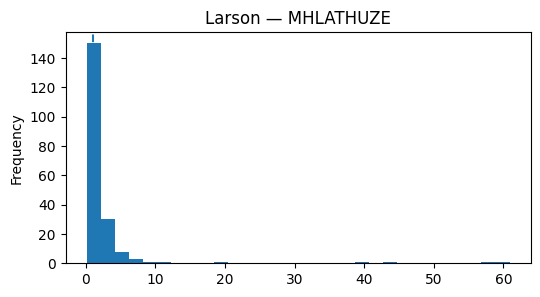

LUVUVU


,effectif
Larson_class,
Moyenne,35
Nette,29
Légère,10
Faible,9
Aucune,1


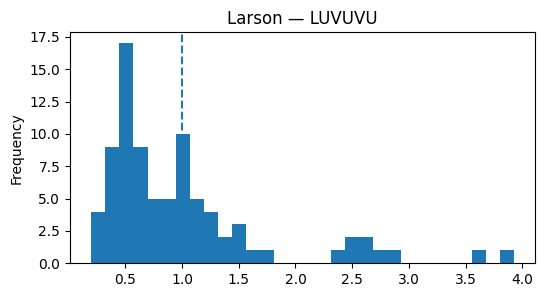

In [10]:
for name,d in [("MHLATHUZE",mhl_i),("LUVUVU",luv_i)]:
    print(name); display(d["Larson_class"].value_counts(dropna=False).to_frame("effectif")); d["Larson_index"].replace([np.inf,-np.inf],np.nan).dropna().plot.hist(bins=30,figsize=(6,3),title=f"Larson — {name}"); plt.axvline(1,ls="--"); plt.show()

## 7. Corrélation avec Larson

In [11]:
for name,d in [("MHLATHUZE",mhl_i),("LUVUVU",luv_i)]:
    cols=[c for c in chem+["Larson_index"] if c in d.columns]; print(name); display(d[cols].corr(numeric_only=True)[["Larson_index"]].sort_values("Larson_index",ascending=False))

MHLATHUZE


,Larson_index
Larson_index,1.000000
Ca,0.785170
SO4,0.588934
Cl,0.540971
TDS,0.470564
EC,0.455748
NO3,0.407623
Na,0.199040
Mg,0.108087
K,0.022980


LUVUVU


,Larson_index
Larson_index,1.000000
Cl,0.627458
K,0.551111
Na,0.539136
SO4,0.517301
TDS,0.462472
EC,0.462472
pH,0.444071
Ca,0.293625
NO3,0.230647


## 8. Langelier

La température n’est pas présente. Le notebook ne calcule donc pas de LSI avec une température inventée. La fonction est prête dans `src/indices_chimiques.py`.

## 9. Jeu commun

In [12]:
cols=chem+["Larson_index","Larson_corrosive"]
a=mhl_i[cols].copy(); a["source"]="MHLATHUZE"
b=luv_i[cols].copy(); b["source"]="LUVUVU"
aggr=pd.concat([a,b],ignore_index=True).replace([np.inf,-np.inf],np.nan).dropna(subset=["Larson_corrosive"]).reset_index(drop=True)
display(aggr.head()); print(aggr.shape)

,pH,EC,TDS,Na,K,Ca,Mg,Cl,HCO3,SO4,NO3,Larson_index,Larson_corrosive,source
0,5.08,246.3,177.3,13.7,5.86,41.30,9.49,27.329,70.15,9.881,1.597,1.028372,1,MHLATHUZE
1,6.22,1058.0,711.0,52.4,8.14,87.20,52.60,145.702,207.40,18.918,16.519,1.440832,1,MHLATHUZE
2,6.62,137.0,99.0,11.3,5.35,6.98,3.31,12.382,70.15,2.155,6.487,0.381833,0,MHLATHUZE
3,6.68,1412.0,957.0,43.3,6.25,82.30,44.80,226.381,216.55,135.851,3.200,3.393133,1,MHLATHUZE
4,6.98,1254.0,863.0,47.2,5.00,102.00,107.00,129.445,341.60,68.583,2.570,1.162286,1,MHLATHUZE


(282, 14)


## 10. Export

In [13]:
save_processed(aggr,DATA_PROCESSED/"aggressiveness_clean.csv")

## 11. Synthèse

Discuter les classes Larson, les différences entre feuilles, l’absence de température pour Langelier et la non-utilisation de `Y` faute de documentation.